# `RadCalNet` Automated Multi-Site Processing of BOA and TOA Reflectance Time-series
### Radiometric reference of Bottom-of-Atmosphere (BOA) &. Top-of-Atmosphere (TOA) Reflectance

| Contributor Information | Details |
| :---: | :---: |
| **Author** | Paul Montesano |
| **Affiliation** | NASA GSFC , ESSIC |
| **Date** | July 9, 2026 |

---

### Notebook Description

This notebook shows a data ingestion and visualization pipeline for processing sequential hyper-spectral measurements from the **Radiometric Calibration Network (`RadCalNet`)**. It programmatically accesses the `RadCalNet` API, compiles input (BOA) and output (TOA) reflectance measurements from individual file, appends data across dates and sites, handles internal NoData data fill values (`9997`, `9998`, `9999`), and returns a final data frame of reference reflectance across all sites for analysis.

The output will be useful to link with coincident pixels from remote sensing measurements.

This exploratory analysis includes time-series from each RadCalNet site:  
+ Railroad Valley Playa (RVUS)  
+ La Crau (LCFR)  
+ Gobabeb (GONA)  
+ Baotou Gravel (BTCN)  
+ Baotou Sandy (BSCN)  
+ Golmud Gobi (GSCN)  

#### Visualization:
1. **True-Color & Infrared Timelines (`plot_boa_vs_toa_with_colors`)**: Generates linear multi-band timelines tracking visible and SWIR bands (encoded via real physical wavelengths with structural data gaps preserved natively.
2. **Full Spectral Signature Profiles (`plot_spectral_signature_curve`)**: Features continuous 400–2500 nm curves for a specific time, applying a localized fuzzy date-matching to plot the available data closest to the specified time.
3. **Atmospheric attenuation (`plot_atmospheric_attenuation`)**: Isolates and graphs the delta values ($\Delta = \text{TOA} - \text{BOA}$) over time to model true atmospheric attenuations.
4. **Diurnal Solar Cycle Overlays (`plot_diurnal_overlay`)**: Stacks multi-year observations against an identical **HH:MM UTC** daily clock axis to visually highlight ground-reflectance changes caused by solar zenith and azimuth geometric paths.


In [51]:
import os
import datetime as dt
import io
import datetime
import configparser
import pandas as pd
import requests

import sys
import subprocess
import configparser
import glob
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.cm as cm
import numpy as np

In [54]:


# 1. Define the raw RadCalNet data
data = {
    "Site Name": [
        "Railroad Valley Playa (RVUS)",
        "La Crau (LCFR)",
        "Gobabeb (GONA)",
        "Baotou Gravel (BTCN)",
        "Baotou Sandy (BSCN)",
        "Golmud Gobi (GSCN)"
    ],
    "Country": ["USA", "France", "Namibia", "China", "China", "China"],
    "Surface Type": ["Clay Dry Lake", "Pebbly Plain", "Desert Sand", "Artificial Grey Gravel", "Natural Sand", "Sandy/Gravel Desert"],
    "Latitude": [38.49700, 43.55885, -23.60020, 40.85140, 40.86500, 36.43440],
    "Longitude": [-115.69000, 4.86447, 15.11960, 109.62910, 109.61550, 94.22510]
}

# 2. Convert raw data into a standard Pandas DataFrame
df = pd.DataFrame(data)

# 3. Create geometry points from Longitude and Latitude columns
geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]

# 4. Initialize the GeoDataFrame with WGS84 coordinate reference system (EPSG:4326)
radcalnet_sites_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# View the resulting GeoDataFrame
radcalnet_sites_gdf

,Site Name,Country,Surface Type,Latitude,Longitude,geometry
0,Railroad Valley Playa (RVUS),USA,Clay Dry Lake,38.49700,-115.69000,POINT (-115.69000 38.49700)
1,La Crau (LCFR),France,Pebbly Plain,43.55885,4.86447,POINT (4.86447 43.55885)
2,Gobabeb (GONA),Namibia,Desert Sand,-23.60020,15.11960,POINT (15.11960 -23.60020)
3,Baotou Gravel (BTCN),China,Artificial Grey Gravel,40.85140,109.62910,POINT (109.62910 40.85140)
4,Baotou Sandy (BSCN),China,Natural Sand,40.86500,109.61550,POINT (109.61550 40.86500)
5,Golmud Gobi (GSCN),China,Sandy/Gravel Desert,36.43440,94.22510,POINT (94.22510 36.43440)


### Download `RadCalNet` time-series at all sites

In [2]:
ADAPT = True

In [3]:
# 1. Safely load credentials from your local file
config = configparser.ConfigParser()

YEAR = "2026"
START_DATE = f"{YEAR}-05-01"
STOP_DATE = f"{YEAR}-06-08"

if ADAPT:
    config.read("/home/pmontesa/code/credentials.ini")
    DATADIR = "/explore/nobackup/projects/CSDA_eval/data/radcalnet"
else:
    config.read("/projects/my-private-bucket/credentials.ini")
    DATADIR = "/projects/my-public-bucket/databank/radcalnet"

In [4]:
# 3. Import and execute the script's main function
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
import radcalnet_api_client
from radcalnetlib import *

In [5]:
SITE_CODE_TO_NAME

{'RVUS': 'Railroad Valley',
 'LCFR': 'La Crau',
 'GONA': 'Gobabeb',
 'BTCN': 'Baotou',
 'BSCN': 'Baotou Sand',
 'GSCN': 'Gobabeb Sand'}

In [6]:
for SITE_CODE in SITE_CODE_TO_NAME.keys():
    
    OUTDIR = f"{DATADIR}/{SITE_CODE}/{YEAR}"
    !mkdir -p $OUTDIR
    
    # 2. Mimic terminal inputs to trigger the main() loop directly
    sys.argv = [
        "radcalnet_api_client.py",
        "--username", config["RadCalNet"]["username"],
        "--password", config["RadCalNet"]["password"],
        "--site", SITE_CODE, 
        "--start-date", START_DATE,
        "--stop-date", STOP_DATE,
        "--fmt", "ascii",
        "--output-dir", f"{OUTDIR}"
    ]
    
    radcalnet_api_client.main()

In [21]:
import importlib
import radcalnetlib
importlib.reload(radcalnetlib)
from radcalnetlib import *

## Example on a single site

### Read in the downloaded data
`input` = `BOA`  
`output` = `TOA`

In [7]:
OUTDIR

'/explore/nobackup/projects/CSDA_eval/data/radcalnet/GSCN/2026'

In [10]:
# Unpack inputs: splits clean reflectance measurements from uncertainty measurements
in_ref_meta, in_ref_spectra, in_unc_meta, in_unc_spectra = (
    compile_directory(OUTDIR, stage="input")
)

# Unpack outputs
out_ref_meta, out_ref_spectra, out_unc_meta, out_unc_spectra = (
    compile_directory(OUTDIR, stage="output")
)

print("--- Cleaned Shapes Verification ---")
print(f"Reflectance Spectra Grid Shape: {in_ref_spectra.shape}")  # (211 rows)
print(f"Uncertainty Spectra Grid Shape: {in_unc_spectra.shape}")  # (211 rows)


--- Cleaned Shapes Verification ---
Reflectance Spectra Grid Shape: (211, 169)
Uncertainty Spectra Grid Shape: (211, 169)


In [11]:
out_ref_spectra.tail()

,2026-05-03 01:00,2026-05-03 01:30,2026-05-03 02:00,2026-05-03 02:30,2026-05-03 03:00,2026-05-03 03:30,2026-05-03 04:00,2026-05-03 04:30,2026-05-03 05:00,2026-05-03 05:30,...,2026-06-05 02:30,2026-06-05 03:00,2026-06-05 03:30,2026-06-05 04:00,2026-06-05 04:30,2026-06-05 05:00,2026-06-05 05:30,2026-06-05 06:00,2026-06-05 06:30,2026-06-05 07:00
Wavelength,,,,,,,,,,,,,,,,,,,,,
2460,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2470,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2480,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2490,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0
2500,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,...,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0,9998.0


In [12]:
print("Your Input Matrix Column Headers look like this:")
print(list(in_ref_spectra.columns[:5]))

Your Input Matrix Column Headers look like this:
['2026-05-03 01:00', '2026-05-03 01:30', '2026-05-03 02:00', '2026-05-03 02:30', '2026-05-03 03:00']


# Plot `RadCalNet` data

### Mask out nodata
#### `todo`: check what we are masking out.. quality classes?


Note:  
when doing multiple site we use `load_site_dataset()` which bakes in a reflectance mask of anything < 2.0

In [13]:
# Mask out any NoData / Fill value entries greater than 9000 across both data frames
in_ref_spectra[in_ref_spectra > 9000] = np.nan
out_ref_spectra[out_ref_spectra > 9000] = np.nan

# Round the index values to ensure clean integer matching remains active
in_ref_spectra.index = np.round(in_ref_spectra.index).astype(int)
out_ref_spectra.index = np.round(out_ref_spectra.index).astype(int)

### Choose some subset daterange within the timeline downloaded

In [14]:
SUBSET_DATERANGE = True

In [39]:
if SUBSET_DATERANGE:
    # Define your target window boundary
    start_date = "2026-06-01"
    stop_date = "2026-06-05"
    
    # Create boolean location masks
    mask_in = (in_ref_spectra.columns >= start_date) & (in_ref_spectra.columns <= stop_date)
    mask_out = (out_ref_spectra.columns >= start_date) & (out_ref_spectra.columns <= stop_date)

    # Extract the subsets
    in_ref_spectra_subset = in_ref_spectra.loc[:, mask_in]
    out_ref_spectra_subset = out_ref_spectra.loc[:, mask_out]
else:
    in_ref_spectra_subset = in_ref_spectra
    out_ref_spectra_subset = out_ref_spectra

In [17]:
in_ref_spectra.head()

,2026-05-03 01:00,2026-05-03 01:30,2026-05-03 02:00,2026-05-03 02:30,2026-05-03 03:00,2026-05-03 03:30,2026-05-03 04:00,2026-05-03 04:30,2026-05-03 05:00,2026-05-03 05:30,...,2026-06-05 02:30,2026-06-05 03:00,2026-06-05 03:30,2026-06-05 04:00,2026-06-05 04:30,2026-06-05 05:00,2026-06-05 05:30,2026-06-05 06:00,2026-06-05 06:30,2026-06-05 07:00
Wavelength,,,,,,,,,,,,,,,,,,,,,
400,0.0781,0.0762,0.0758,0.0757,0.0751,0.0752,0.0758,0.0767,0.0774,0.0781,...,0.0678,0.0689,0.0684,0.0701,0.0696,0.0719,0.0728,0.0727,0.0720,0.0712
410,0.0902,0.0881,0.0878,0.0877,0.0876,0.0880,0.0888,0.0899,0.0906,0.0913,...,0.0789,0.0804,0.0801,0.0822,0.0816,0.0842,0.0854,0.0853,0.0846,0.0837
420,0.1059,0.1038,0.1033,0.1033,0.1033,0.1039,0.1049,0.1061,0.1071,0.1078,...,0.0931,0.0949,0.0947,0.0972,0.0966,0.0996,0.1010,0.1009,0.1001,0.0990
430,0.1190,0.1167,0.1161,0.1162,0.1163,0.1169,0.1181,0.1193,0.1205,0.1213,...,0.1049,0.1070,0.1067,0.1096,0.1088,0.1123,0.1137,0.1137,0.1128,0.1115
440,0.1256,0.1234,0.1228,0.1228,0.1230,0.1237,0.1248,0.1261,0.1273,0.1282,...,0.1111,0.1133,0.1130,0.1160,0.1152,0.1188,0.1203,0.1202,0.1193,0.1179


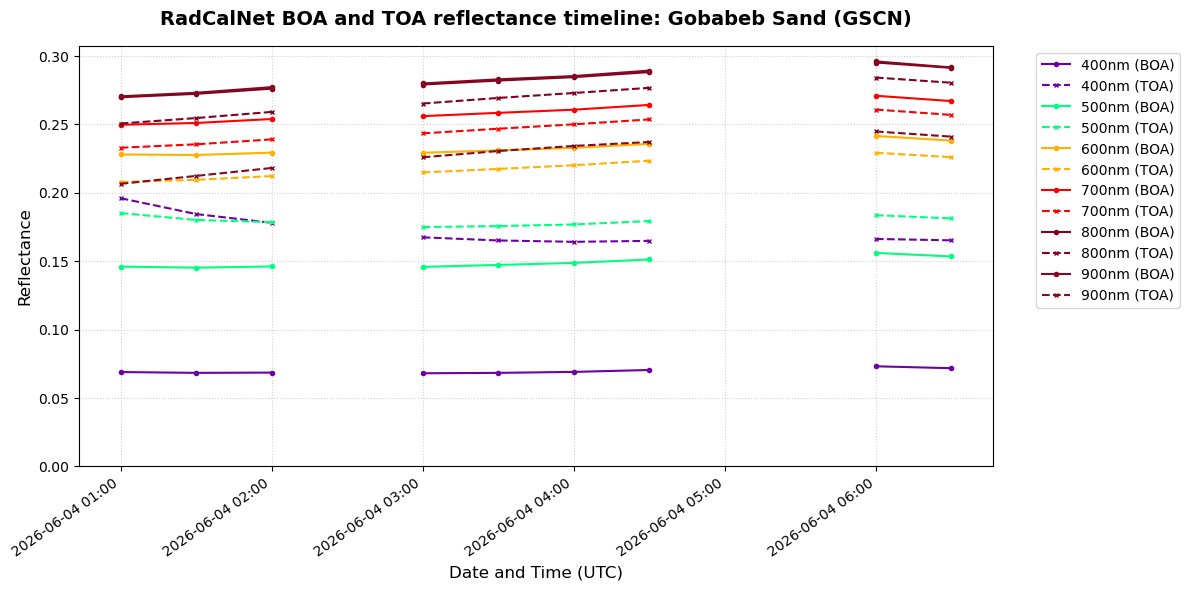

In [42]:
# Now define your target selection range
# selected_wavelengths = [*range(500, 510, 10), *range(900, 910, 10)]
selected_wavelengths = [*range(400, 1000, 100)]

# Generate the plot
plot_boa_vs_toa_with_colors(
    input_spectra=in_ref_spectra_subset,
    output_spectra=out_ref_spectra_subset,
    wavelengths=selected_wavelengths,
    site_name=f"{SITE_CODE}",
)


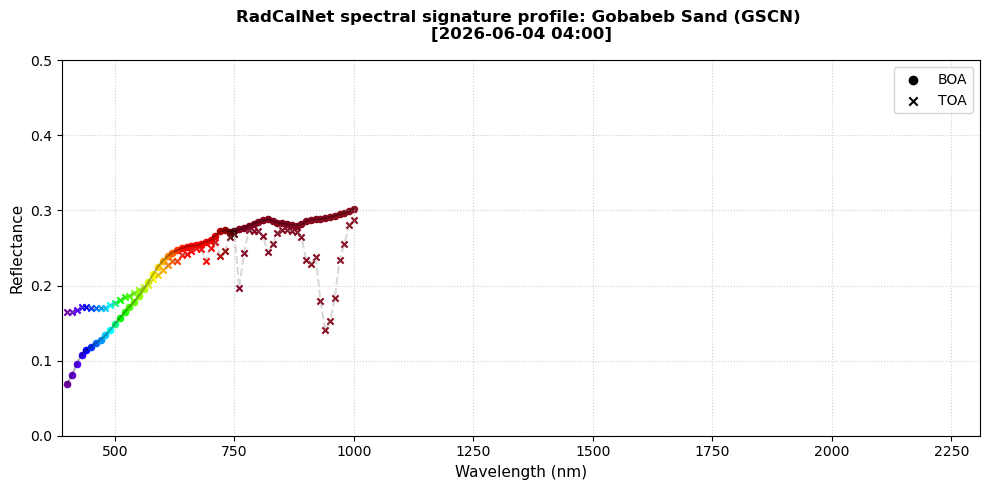

In [18]:
# Select a single date and time present in your dataset
target_time = "2026-06-04 04:00"

# Generate the plot
plot_spectral_signature_curve(
    input_spectra=in_ref_spectra_subset,
    output_spectra=out_ref_spectra_subset,
    timestamp_str=target_time,
    site_name=SITE_CODE
)


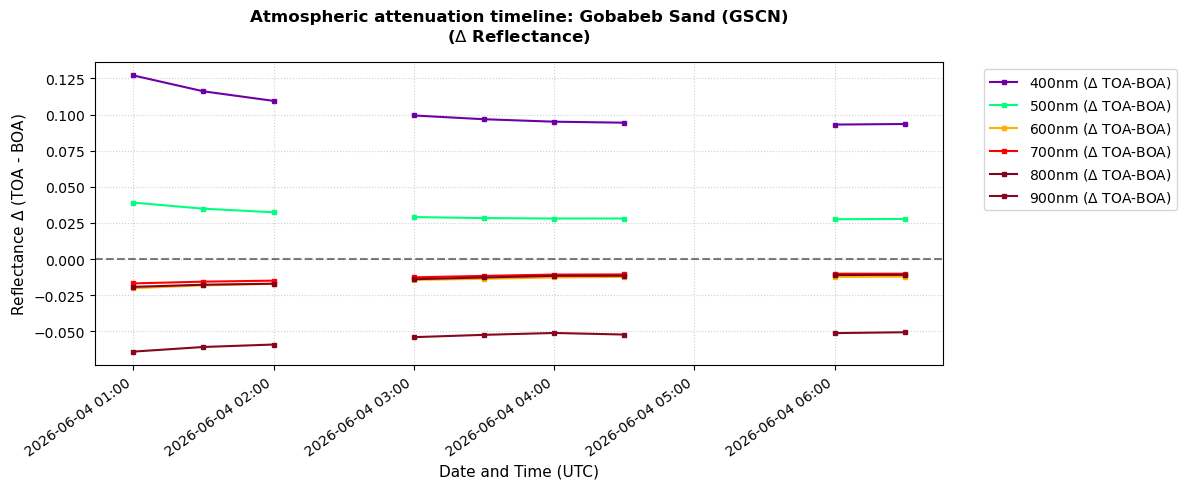

In [41]:
# Generate the plot
plot_atmospheric_attenuation(
    input_spectra=in_ref_spectra_subset,
    output_spectra=out_ref_spectra_subset,
    wavelengths=selected_wavelengths,
    site_name=SITE_CODE
)


--- Running Diurnal Trend Overlay for BOA ---


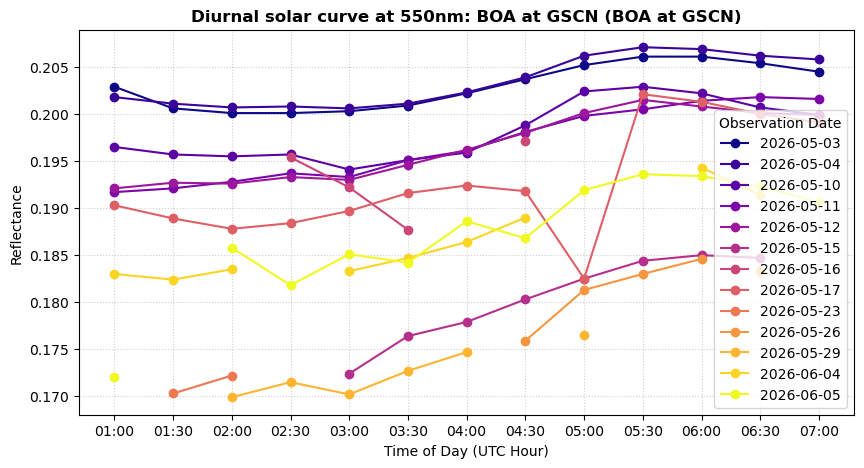


--- Running Diurnal Trend Overlay for TOA ---


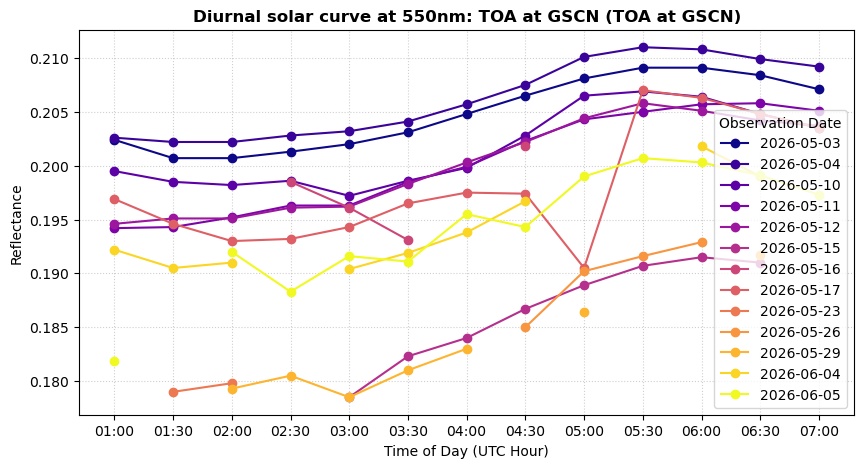

In [43]:
# Choose a single wavelength channel to analyze across all days
target_wavelength = 550  # Green band element

print("--- Running Diurnal Trend Overlay for BOA ---")
plot_diurnal_overlay(spectra_df=in_ref_spectra, wavelength=target_wavelength, site_name=f"BOA at {SITE_CODE}")

print("\n--- Running Diurnal Trend Overlay for TOA ---")
plot_diurnal_overlay(spectra_df=out_ref_spectra, wavelength=target_wavelength, site_name=f"TOA at {SITE_CODE}")


# Multi-site plotting

In [44]:
importlib.reload(radcalnetlib)
from radcalnetlib import *

In [45]:
DATADIR

'/explore/nobackup/projects/CSDA_eval/data/radcalnet'

In [46]:
# Define the complete list of 4-letter RadCalNet station codes
site_codes = ["BSCN", "BTCN", "GONA", "GSCN", "LCFR", "RVUS"]

# Initialize an empty list to gather the individual long-form frames
all_sites_compiled = []

print("Starting master compilation loop across all RadCalNet directories...\n")

for site in site_codes:
    print(f"-> Extracting and parsing data for site station: {site}")
    
    # Extract Ground measurements (BOA)
    site_boa = load_site_dataset(DATADIR, site, stage="input")
    
    # Extract TOA
    site_toa = load_site_dataset(DATADIR, site, stage="output")
    
    # Only collect data frames if the site folders contained valid, processed data files
    if not site_boa.empty:
        all_sites_compiled.append(site_boa)
    if not site_toa.empty:
        all_sites_compiled.append(site_toa)

# Concatenate all rows together into one massive long-form database
if all_sites_compiled:
    master_spectral_df = pd.concat(all_sites_compiled, axis=0, ignore_index=True)
    print("\n======================================================")
    print(" COMPILATION COMPLETE SUCCESSFULLY")
    print(f" Total rows in global database: {master_spectral_df.shape[0]:,}")
    print(f" Unique stations successfully mapped: {master_spectral_df['Site'].unique().tolist()}")
    print("======================================================")
else:
    print("\nError: No valid spectral data frames could be compiled from the paths.")

Starting master compilation loop across all RadCalNet directories...

-> Extracting and parsing data for site station: BSCN
-> Extracting and parsing data for site station: BTCN
-> Extracting and parsing data for site station: GONA
-> Extracting and parsing data for site station: GSCN
-> Extracting and parsing data for site station: LCFR
-> Extracting and parsing data for site station: RVUS

 COMPILATION COMPLETE SUCCESSFULLY
 Total rows in global database: 674,586
 Unique stations successfully mapped: ['BSCN', 'BTCN', 'GONA', 'GSCN', 'LCFR', 'RVUS']


### Set target bands that you want to plot

In [47]:
# Unpack your targeted bands across visible and infrared spectrums
selected_wavelengths = [*range(400, 1000, 100), *range(900, 930, 10)]

### Plot site time-series for target bands for all sites

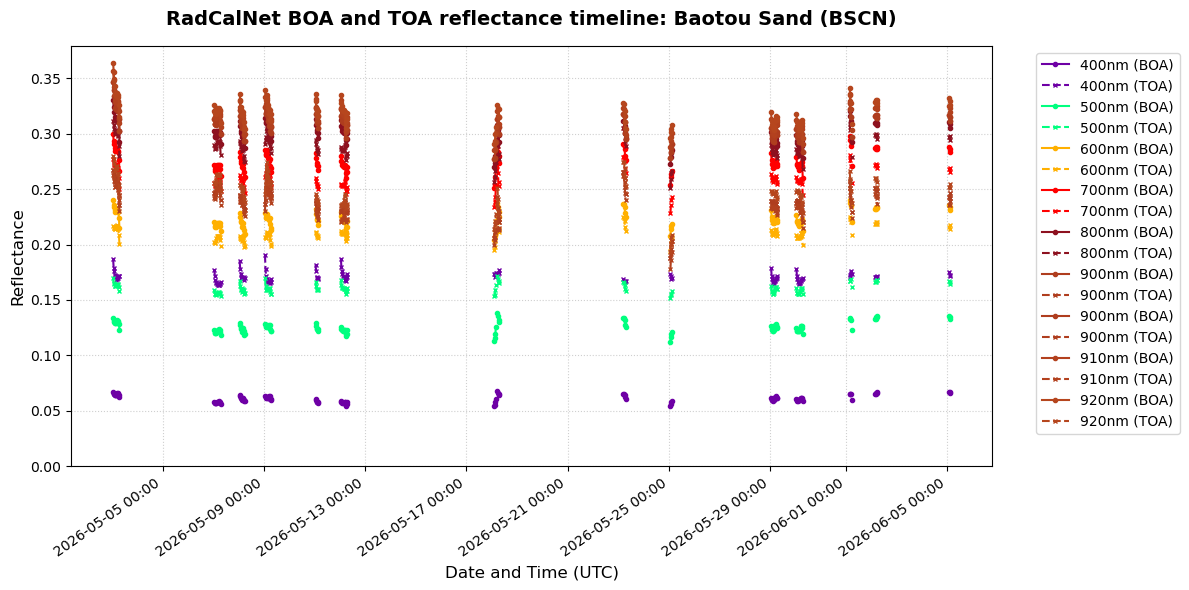

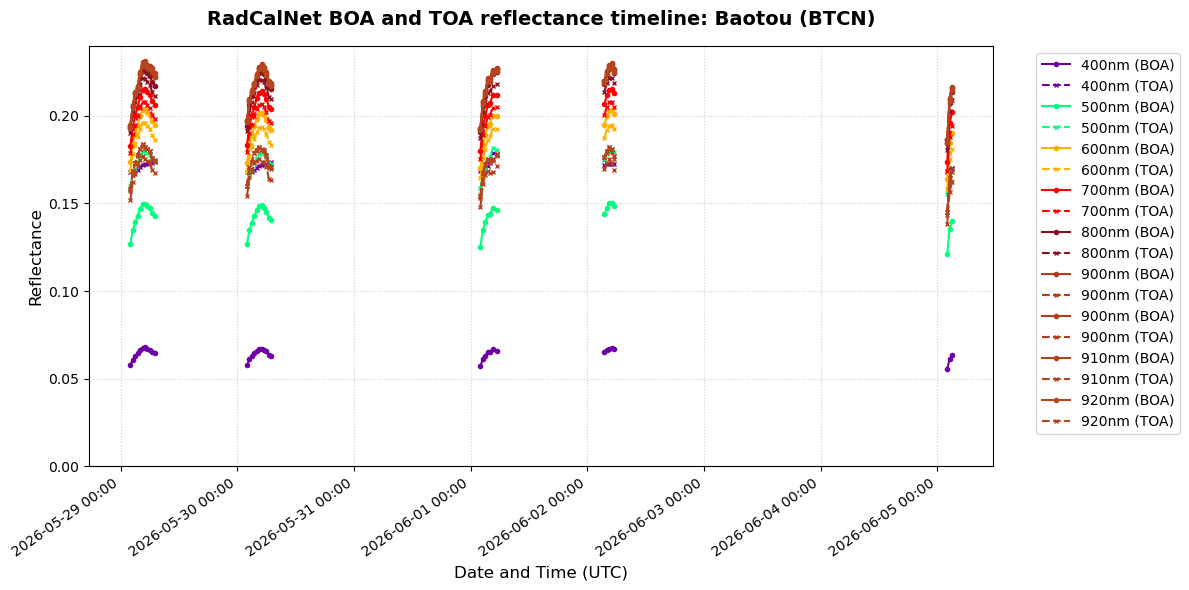

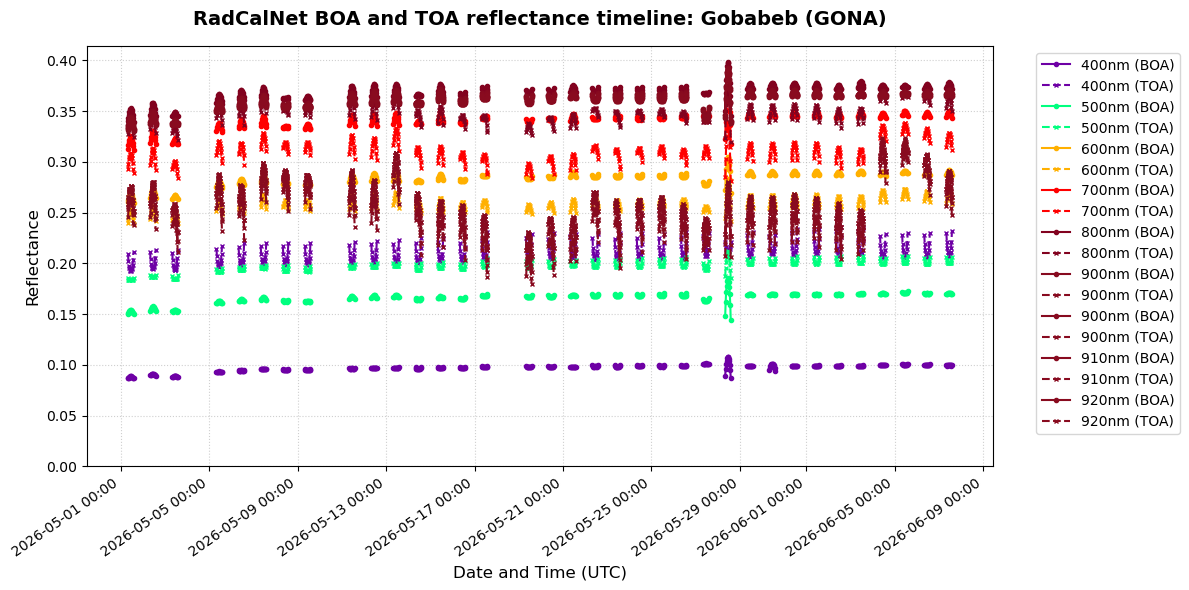

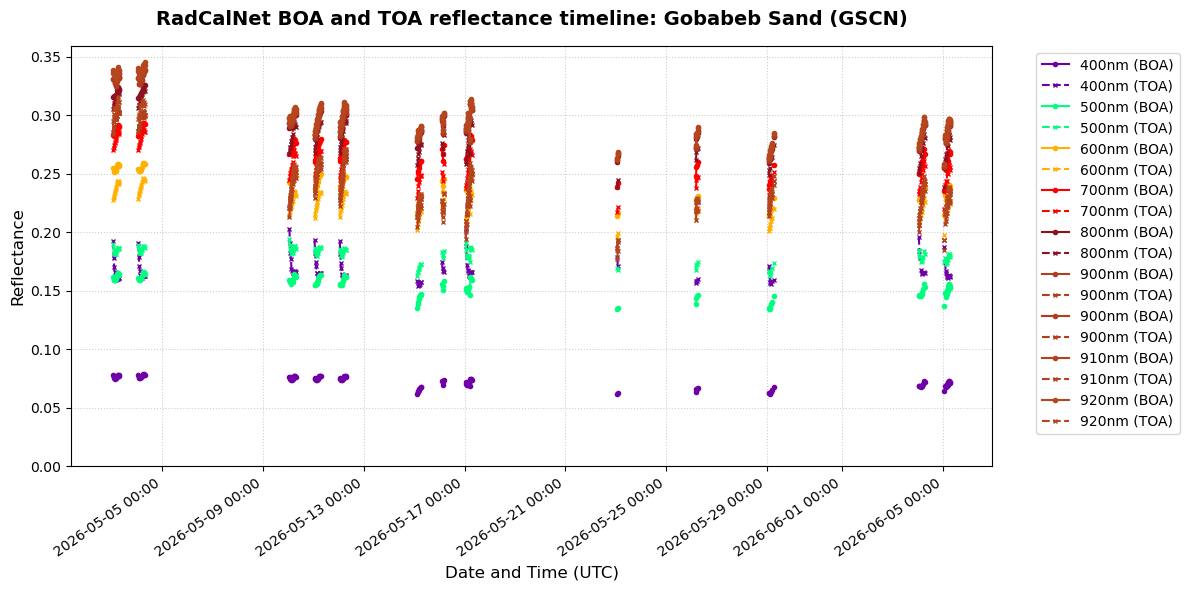

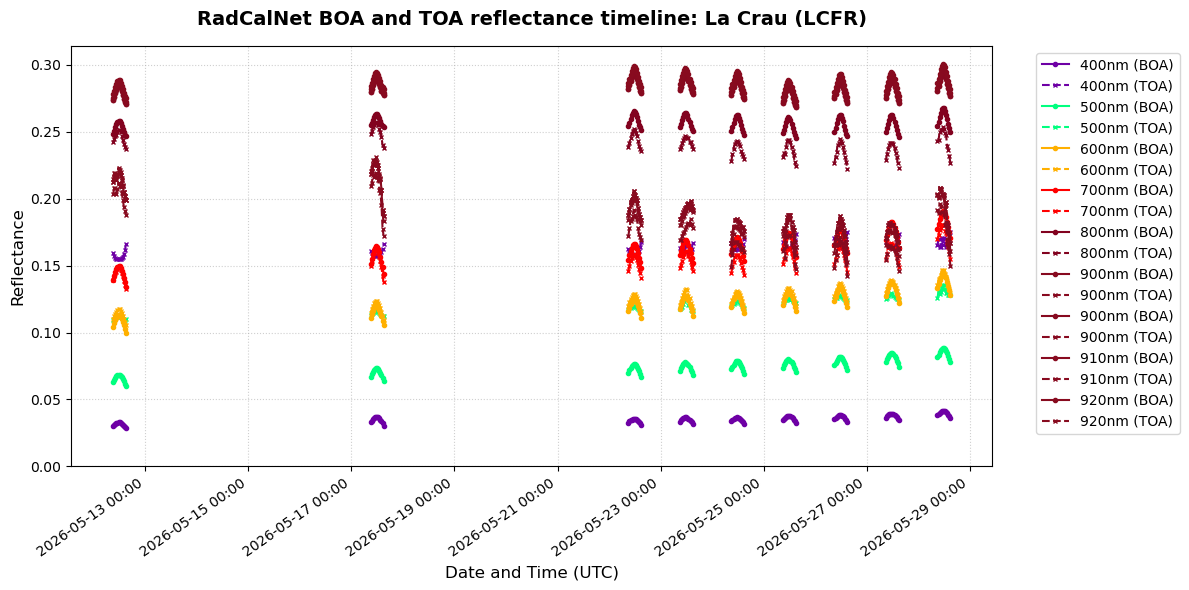

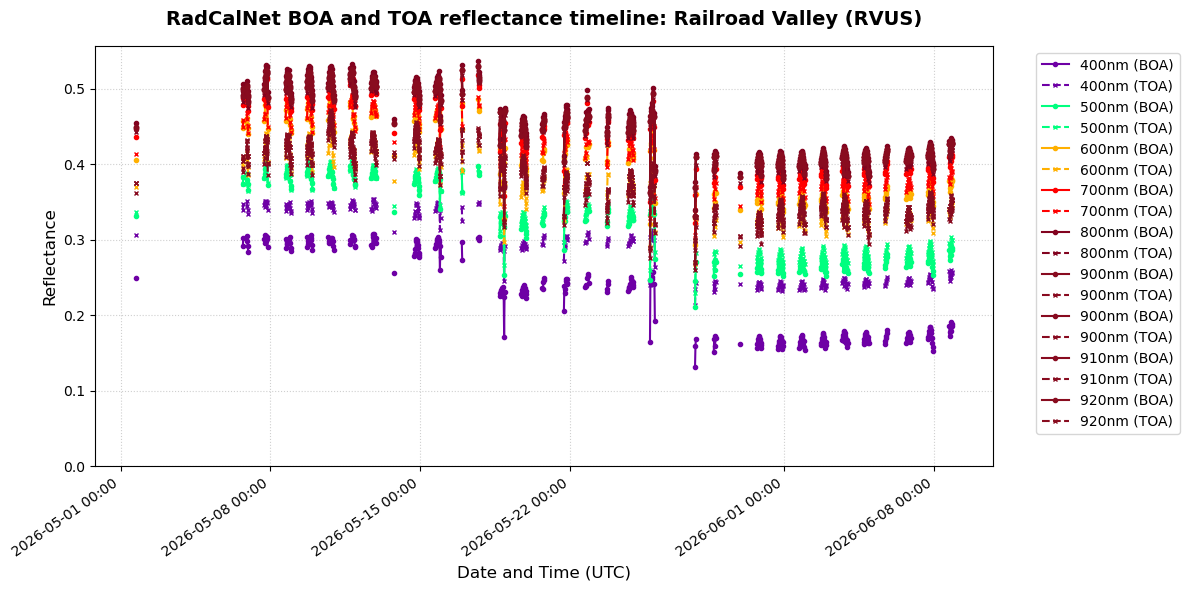

In [48]:
# Run the timelines block
plot_multi_site_timelines_with_colors(master_spectral_df, wavelengths=selected_wavelengths)

### Plot spectral signatures for a target date across all sites


Site BSCN: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-02 03:30


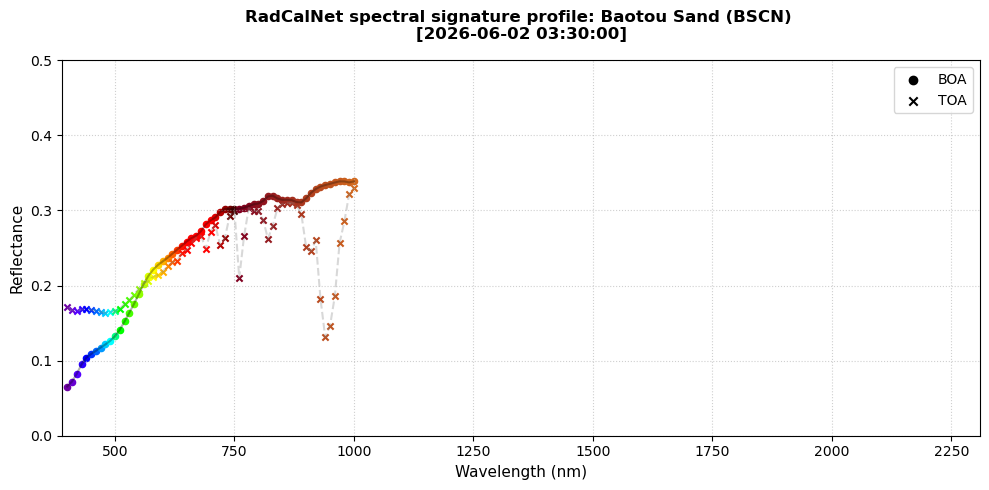


Site BTCN: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-02 03:30


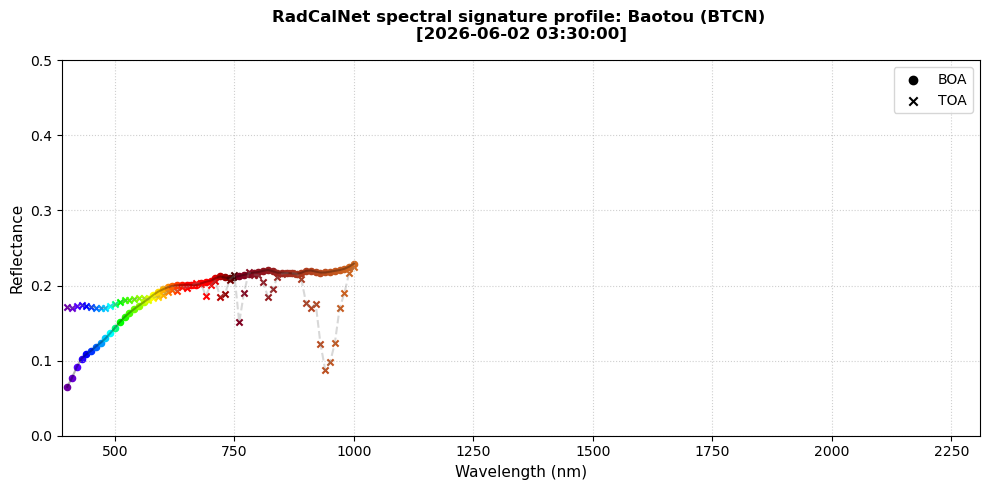


Site GONA: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-01 14:00


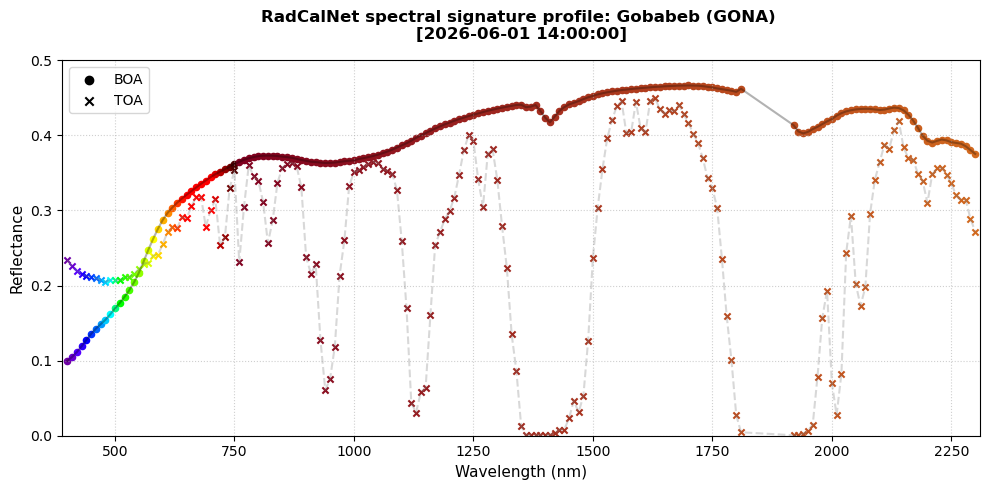


Site GSCN: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-04 01:00


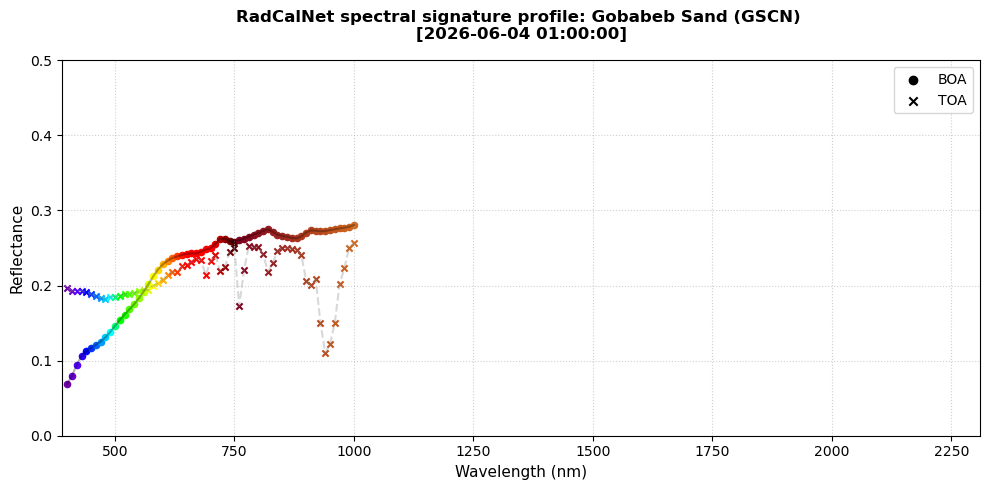


Site LCFR: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-05-28 15:00


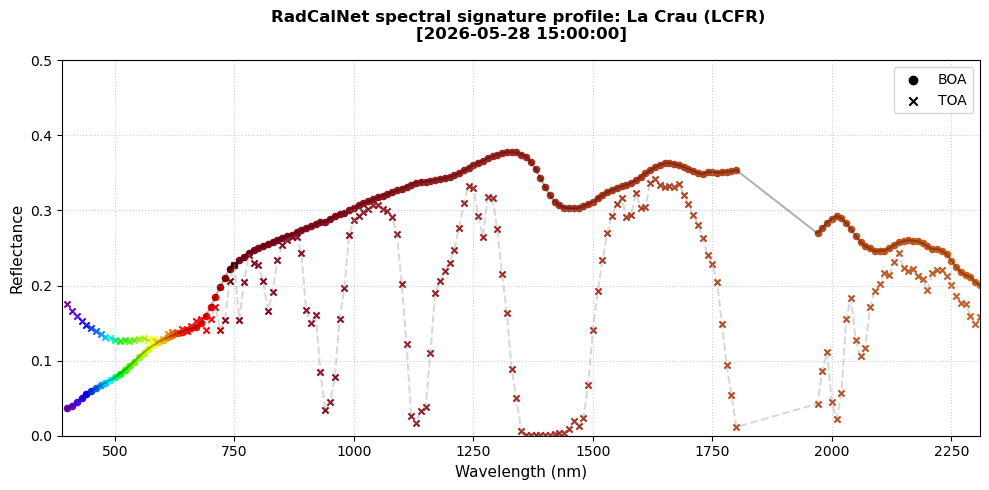


Site RVUS: Target date is 2026-06-01 17:00.
-> Closest available record found at: 2026-06-01 17:00


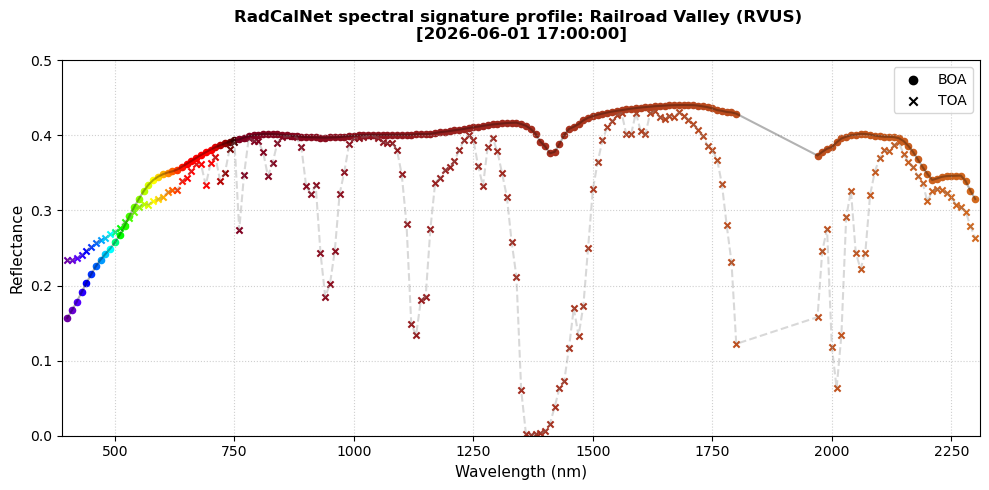

In [25]:
plot_multi_site_signatures(master_spectral_df, target_date_str="2026-06-01 17:00")

### Plot site attenuation curves for a target bands across all sites

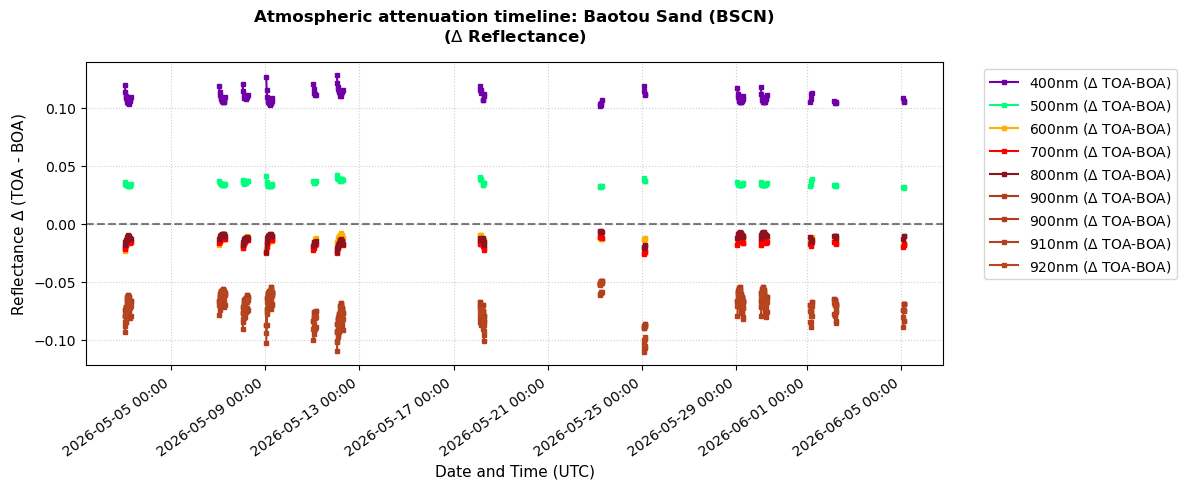

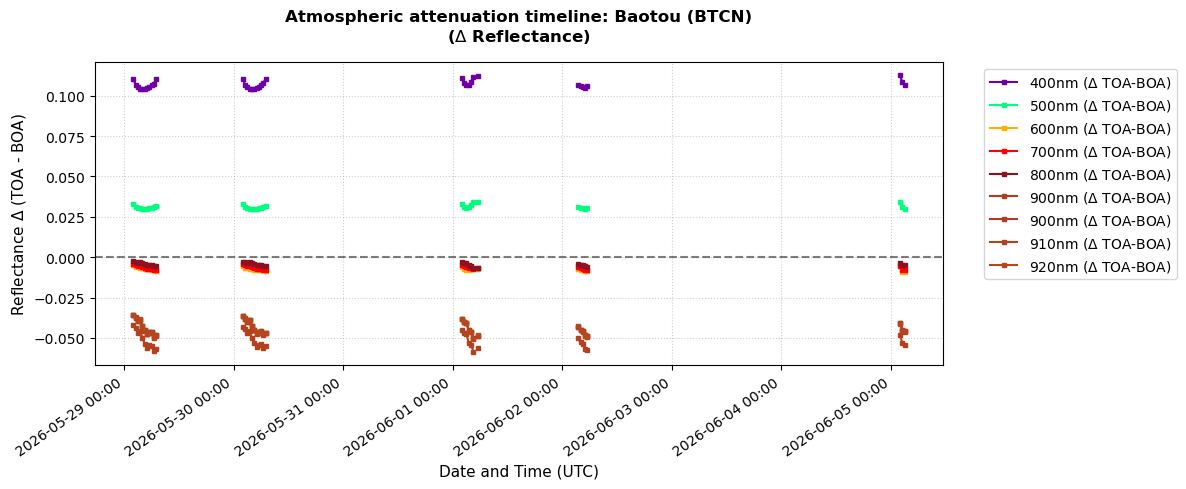

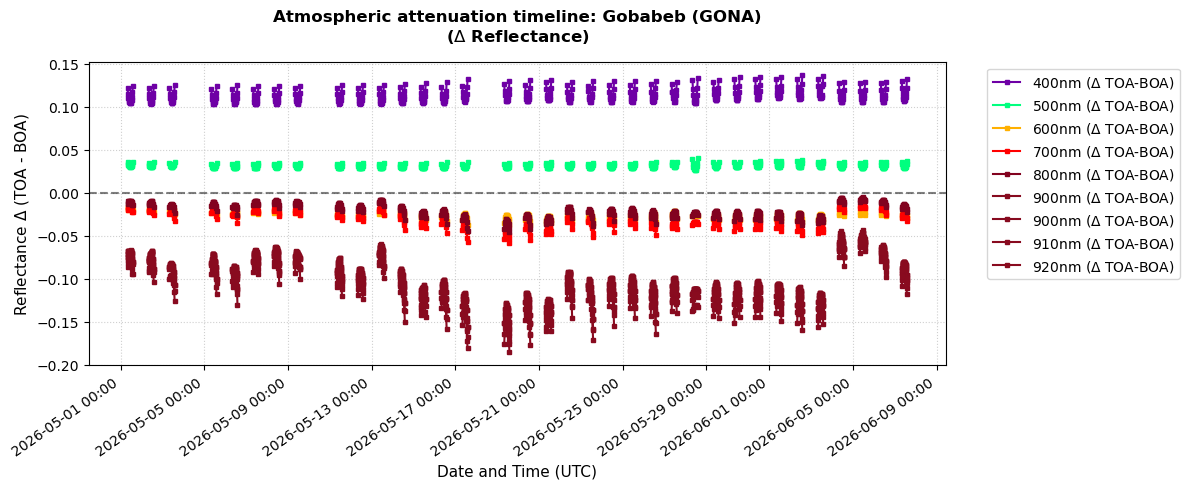

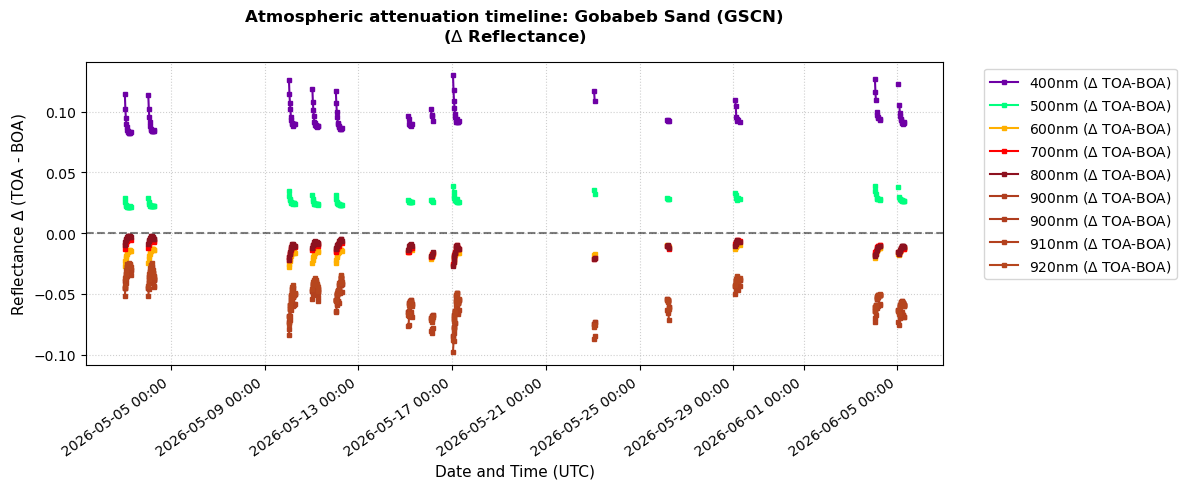

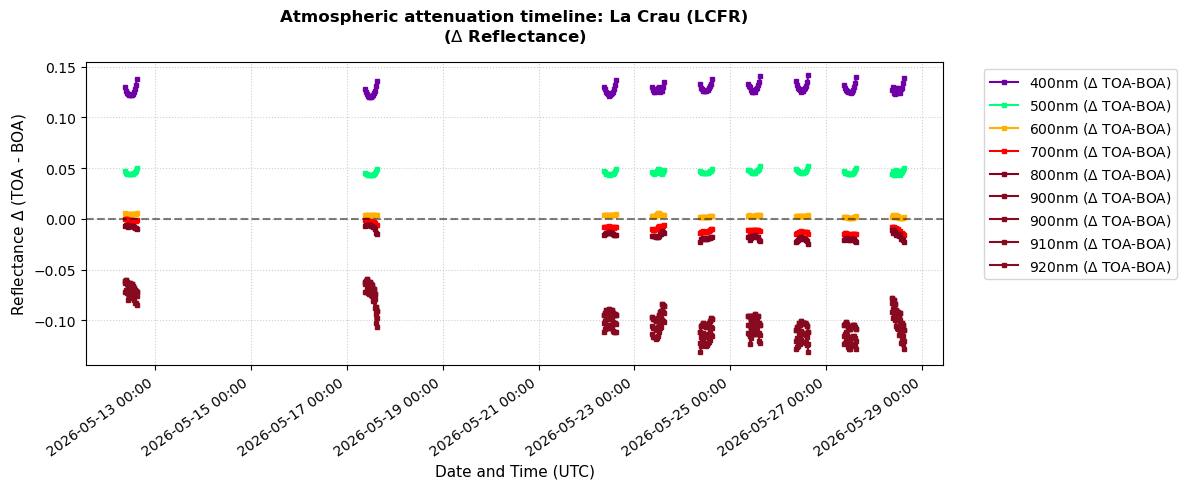

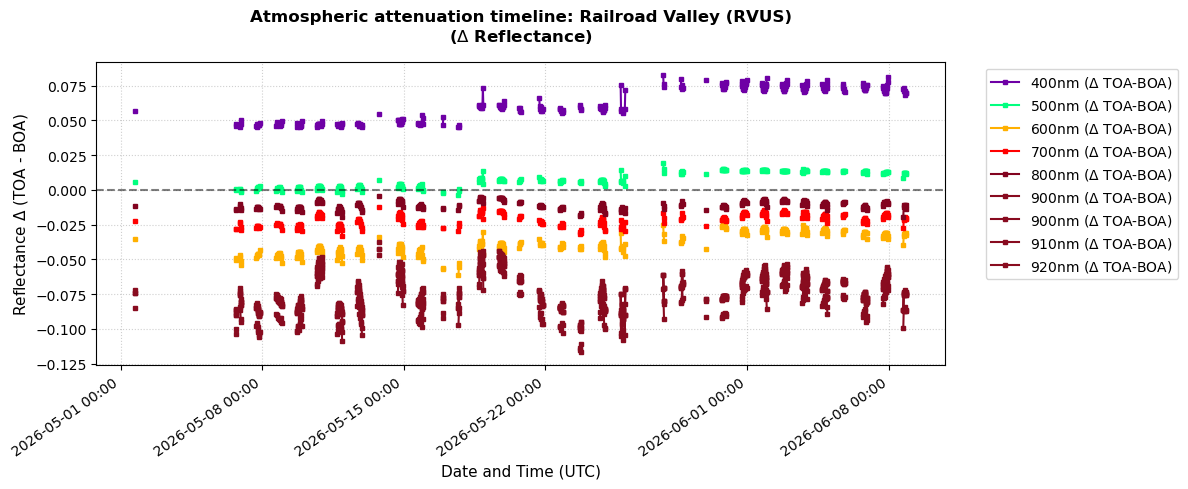

In [49]:
# Run site attenuation curves
plot_multi_site_attenuation(master_spectral_df, wavelengths=selected_wavelengths)

### Plot diurnal curves for a target wavelenth across all sites


--- Diurnal Ground Trend (BOA) for Station: BSCN ---


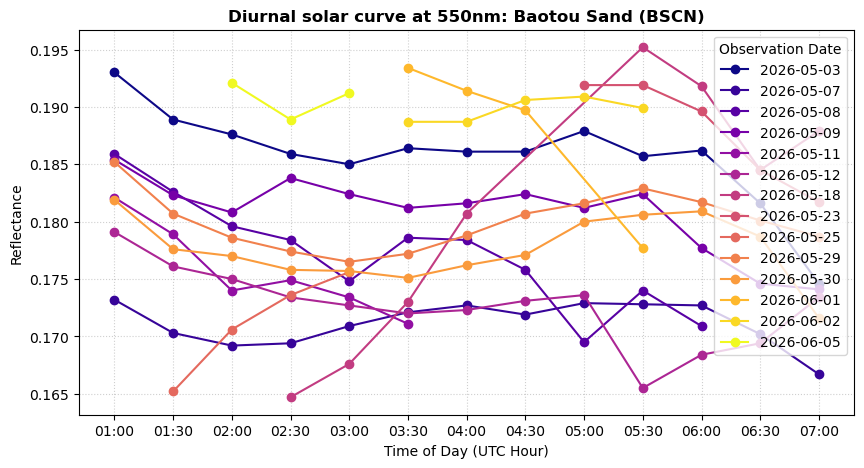


--- Diurnal Ground Trend (BOA) for Station: BTCN ---


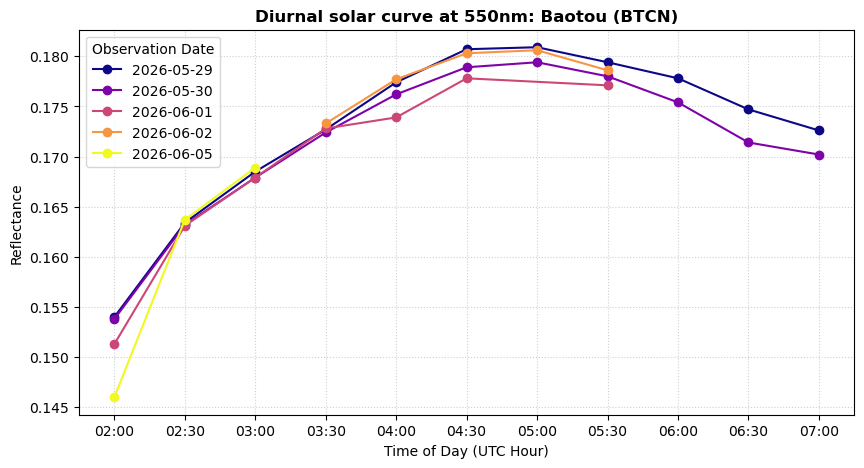


--- Diurnal Ground Trend (BOA) for Station: GONA ---


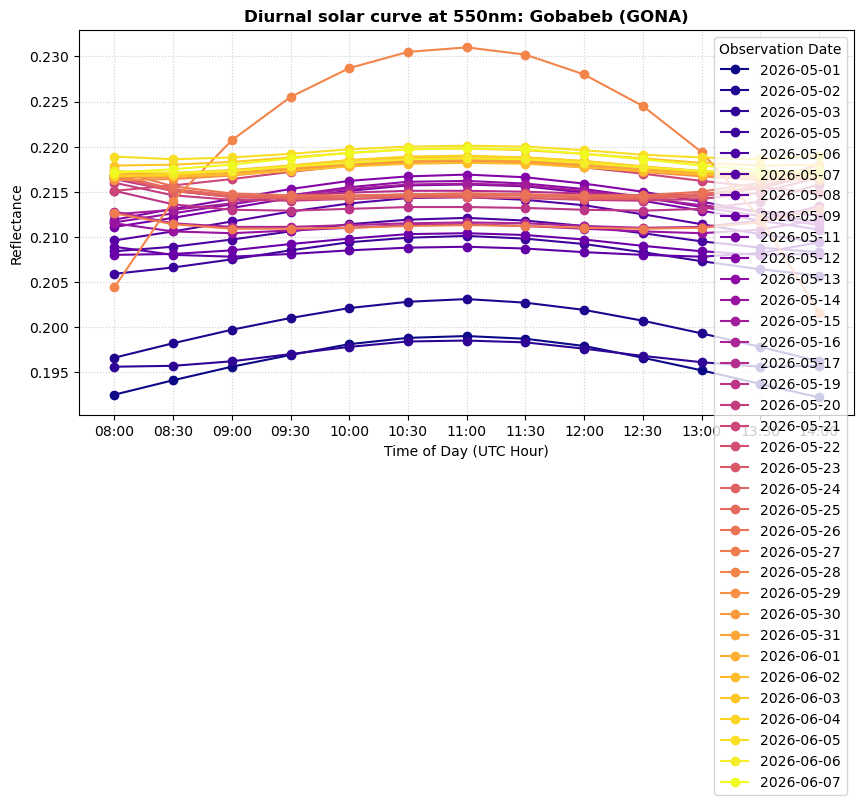


--- Diurnal Ground Trend (BOA) for Station: GSCN ---


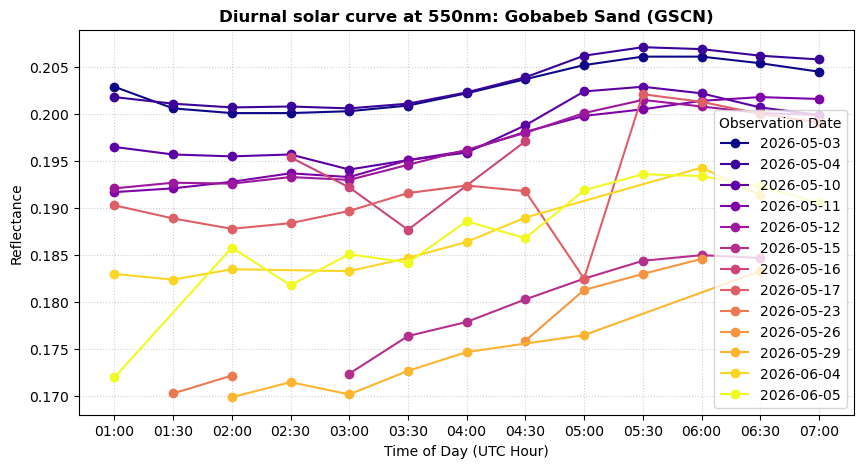


--- Diurnal Ground Trend (BOA) for Station: LCFR ---


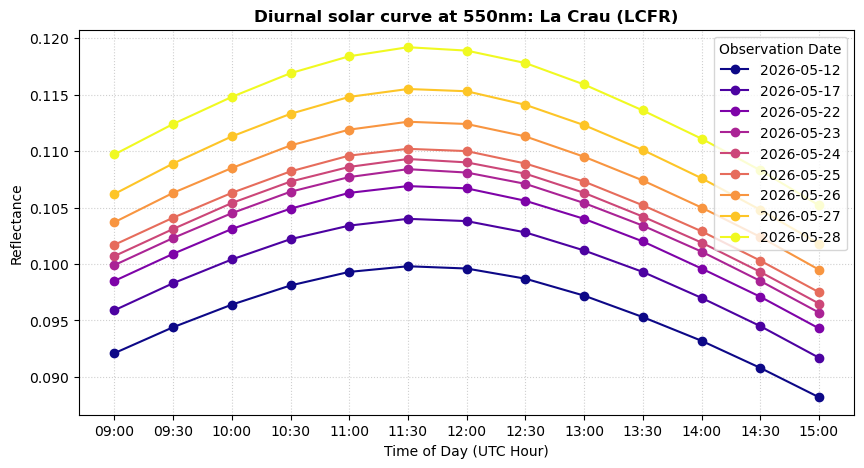


--- Diurnal Ground Trend (BOA) for Station: RVUS ---


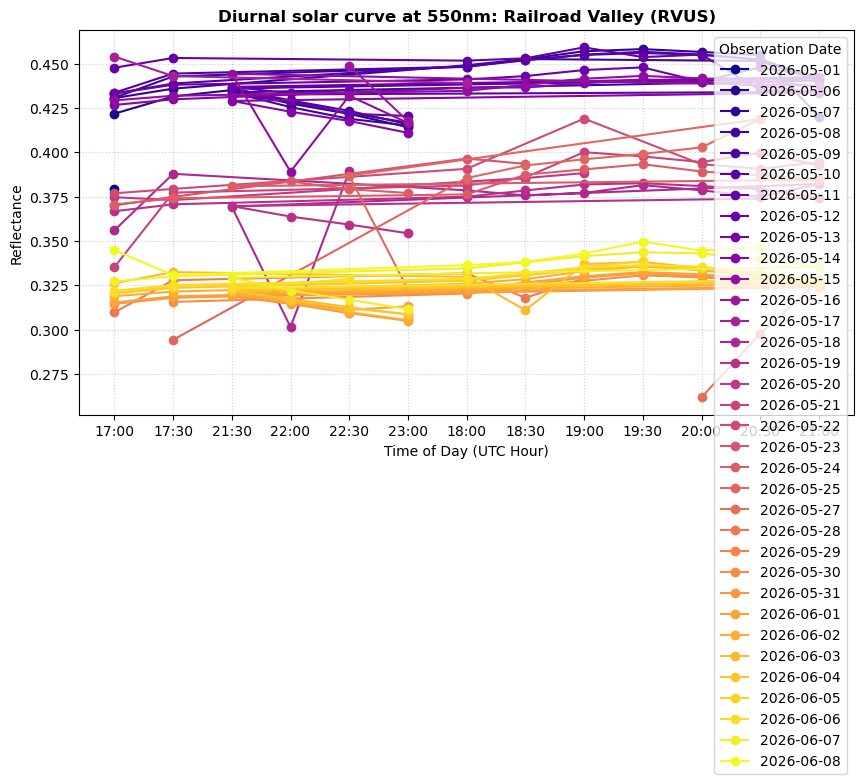

In [50]:
# 5. Run diurnal clock trends at 550nm
plot_multi_site_diurnal(master_spectral_df, target_wavelength=550)